## Visualização dos dados:

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="talk")

def analyze_csv(path):
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"Arquivo não encontrado: {path}\n")
        return

    print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas\n")
    print("Primeiras linhas:")
    print(df.head(), "\n")

    if "radiant_win" in df.columns:
        counts = df["radiant_win"].value_counts()
        percentages = df["radiant_win"].value_counts(normalize=True).sort_index() 

        print("Distribuição de resultados (radiant_win):")
        print(pd.DataFrame({
            "Contagem": counts,
            "Percentual (%)": percentages.round(2)
        }), "\n")

        # Preparar gráfico
        plt.figure(figsize=(6,4))
        ax = sns.barplot(
            x=counts.index.astype(str),
            y=counts.values,
            palette=["#1f77b4", "#ff7f0e"]
        )

        # Adicionar valores sobre as barras
        for i, (count, pct) in enumerate(zip(counts.values, percentages)):
            ax.text(i, count + (counts.max() * 0.03),
                    f"{count}\n({pct:.1f}%)",
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color="#333333")

        ax.set_xlabel("Radiant Win (0 = Dire, 1 = Radiant)", fontsize=12)
        ax.set_ylabel("Número de Partidas", fontsize=12)
        plt.ylim(0, counts.max() * 1.25)

        sns.despine(left=True, bottom=True)
        plt.tight_layout()
        plt.show()
    else:
        print("Coluna 'radiant_win' não encontrada.\n")


## Dados limpos + conversão ID's para nomes de heróis:

Dimensões: 110 linhas x 5 colunas

Primeiras linhas:
   radiant_win   radiant_team_sorted        dire_team_sorted                                                                     radiant_heroes  \
0        False   [1, 17, 44, 49, 58]     [7, 31, 41, 75, 82]  ['Anti-Mage', 'Storm Spirit', 'Phantom Assassin', 'Dragon Knight', 'Enchantress']   
1        False    [1, 2, 11, 51, 68]  [7, 60, 109, 114, 131]            ['Anti-Mage', 'Axe', 'Shadow Fiend', 'Clockwerk', 'Ancient Apparition']   
2         True   [1, 2, 40, 48, 123]    [30, 44, 49, 52, 74]                             ['Anti-Mage', 'Axe', 'Venomancer', 'Luna', 'Hoodwink']   
3         True     [1, 2, 5, 10, 26]    [12, 30, 52, 67, 84]                        ['Anti-Mage', 'Axe', 'Crystal Maiden', 'Morphling', 'Lion']   
4        False  [1, 27, 91, 94, 128]   [2, 33, 38, 109, 121]                         ['Anti-Mage', 'Shadow Shaman', 'Io', 'Medusa', 'Snapfire']   

                                                                

C:\Users\izalo\AppData\Local\Temp\ipykernel_14352\2162799026.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


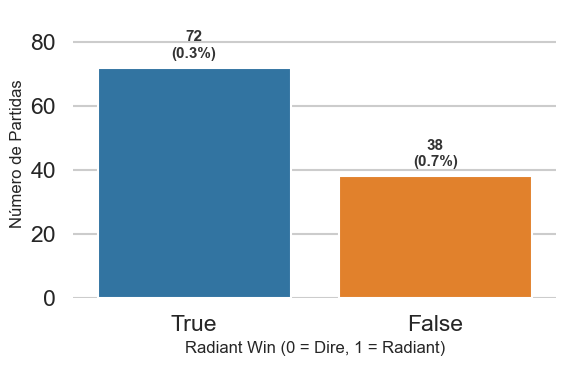

In [8]:
analyze_csv("../data/processed/matches_clean.csv")